# Agromonitor Jateng - Machine Learning Prediction
## Fase 4: Pemodelan Prediksi Harga Komoditas dengan ARIMA

Notebook ini berisi proses _End-to-End_ (E2E) untuk:
1. **Load Data:** Mengambil data historis harga komoditas ril Jawa Tengah dari folder `storage`.
2. **Eksplorasi Data (EDA):** Melihat tren dan volatilitas harga.
3. **Uji Stasioneritas:** Menggunakan Augmented Dickey-Fuller (ADF) test.
4. **Training Model:** Membangun model ARIMA (AutoRegressive Integrated Moving Average).
5. **Evaluasi:** Menghitung skor RMSE dan MAPE.
6. **Forecasting:** Memprediksi harga 14 hari ke depan beserta interval kepercayaannya (Confidence Interval 95%).

In [1]:
# Install library yang dibutuhkan (jika belum ada)
# !python3 -m pip install pandas numpy matplotlib statsmodels scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import glob
import os

import warnings
warnings.filterwarnings('ignore')

### 1. Data Preparation
Kita memuat seluruh data dari folder `../storage` yang berisi file CSV bulanan Jawa Tengah. Kita memproses data ini dengan memfilter komoditas terpilih (default: Beras Medium), membuang data harga kosong/nol, dan menghitung rata-rata harian di seluruh kabupaten/kota.

Menemukan file CSV: ['harga_pokok_jateng_2026-04-01_2026-04-30.csv', 'harga_pokok_jateng_2026-03-01_2026-03-31.csv', 'harga_pokok_jateng_2026-02-01_2026-02-28.csv', 'harga_pokok_jateng_2026-01-01_2026-01-31.csv']

Total data historis Beras Medium: 79 hari.

Tampilan 5 Data Terakhir:
                   Price
Date                    
2026-04-24  13293.942857
2026-04-27  13303.457143
2026-04-28  13294.885714
2026-04-29  13290.114286
2026-04-30  13285.371429


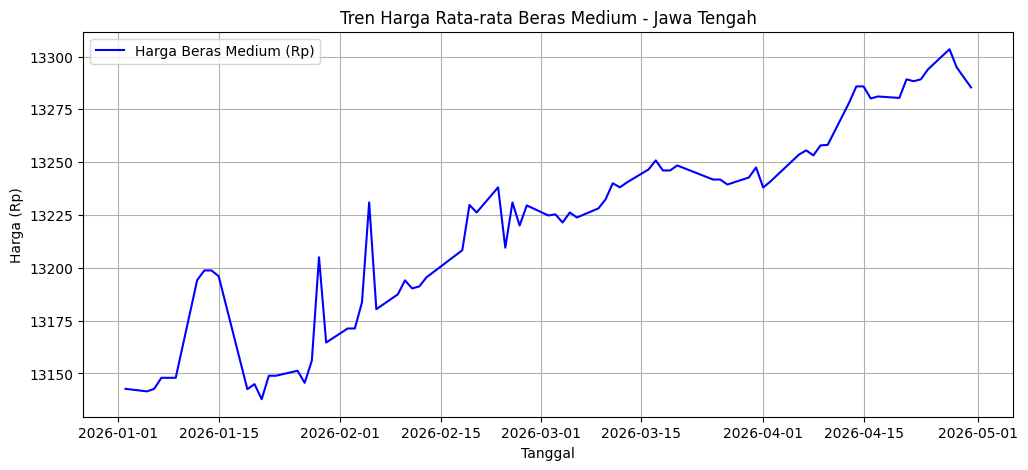

In [3]:
# Path ke folder storage relatif dari folder notebook
storage_dir = '../storage'
csv_files = glob.glob(os.path.join(storage_dir, 'harga_pokok_jateng_*.csv'))

print("Menemukan file CSV:", [os.path.basename(f) for f in csv_files])

# Membaca seluruh file CSV dan menggabungkannya
df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

raw_df = pd.concat(df_list, ignore_index=True)

# Mengonversi kolom tanggal ke datetime
raw_df['tanggal_awal'] = pd.to_datetime(raw_df['tanggal_awal'], format='%d/%m/%Y')

# Tentukan komoditas yang ingin diprediksi (Beras Medium sebagai contoh utama)
commodity_name = 'Beras Medium'
df_commodity = raw_df[raw_df['komoditas'] == commodity_name].copy()

# Filter baris yang harganya 0 (data tidak tercatat/kosong)
df_commodity = df_commodity[df_commodity['harga_tanggal_awal'] > 0]

# Agregasi harian: Rata-rata harga di seluruh wilayah Jawa Tengah
df_daily = df_commodity.groupby('tanggal_awal')['harga_tanggal_awal'].mean().reset_index()
df_daily.columns = ['Date', 'Price']
df_daily.set_index('Date', inplace=True)
df_daily.sort_index(inplace=True)

# Salin ke DataFrame utama 'df' untuk menjaga kompatibilitas dengan sisa kode
df = df_daily.copy()

print(f"\nTotal data historis {commodity_name}: {len(df)} hari.")
print("\nTampilan 5 Data Terakhir:")
print(df.tail())

# Visualisasi
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Price'], label=f'Harga {commodity_name} (Rp)', color='blue')
plt.title(f'Tren Harga Rata-rata {commodity_name} - Jawa Tengah')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.grid(True)
plt.show()

### 2. Uji Stasioneritas Data
Model ARIMA mensyaratkan data bersifat stasioner. Kita cek dengan _Augmented Dickey-Fuller Test_.

In [4]:
def adf_test(series):
    result = adfuller(series.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Data Stasioner (Tolak H0)")
    else:
        print("Data Tidak Stasioner (Gagal Tolak H0) -> Butuh Differencing (d > 0)")

adf_test(df['Price'])

ADF Statistic: 0.2708009213365094
p-value: 0.9759644679616195
Data Tidak Stasioner (Gagal Tolak H0) -> Butuh Differencing (d > 0)


### 3. Model Training (ARIMA)
Membagi data menjadi data latih (80%) dan data uji (20%).

In [5]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Data Latih: {len(train)} hari, Data Uji: {len(test)} hari")

# Fit ARIMA Model (Order p=5, d=1, q=0 sebagai contoh awal)
# Order (p, d, q) bisa dioptimasi menggunakan auto_arima dari pmdarima nantinya.
model = ARIMA(train['Price'], order=(5, 1, 0))
fitted_model = model.fit()

print(fitted_model.summary())

Data Latih: 63 hari, Data Uji: 16 hari
                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                   63
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -257.323
Date:                Wed, 20 May 2026   AIC                            526.647
Time:                        22:26:56   BIC                            539.409
Sample:                             0   HQIC                           531.658
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2755      0.100     -2.759      0.006      -0.471      -0.080
ar.L2         -0.0648      0.221     -0.294      0.769      -0.498       0.368
ar.L3        

### 4. Evaluasi Model (RMSE & MAPE)

RMSE: Rp 34.68
MAPE: 0.25%


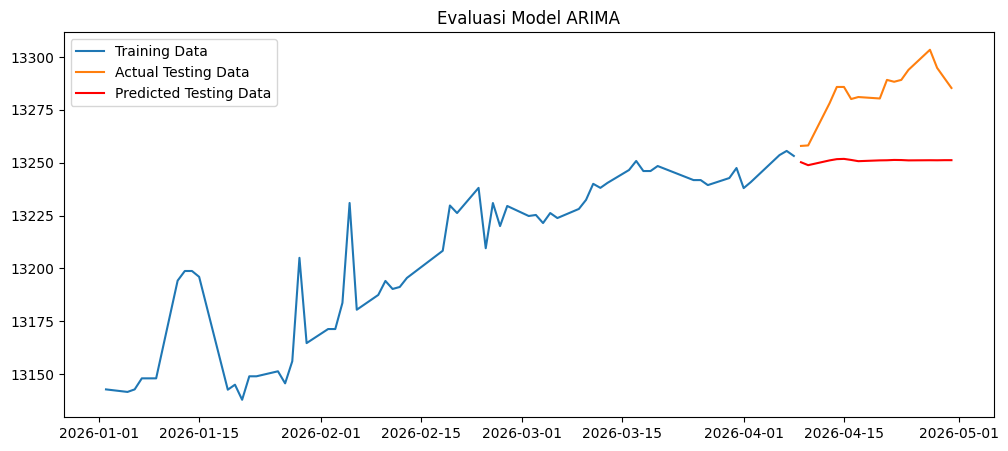

In [6]:
# Melakukan prediksi pada rentang testing
predictions = fitted_model.forecast(steps=len(test))
test = test.copy()  # Menghindari SettingWithCopyWarning
test['Predicted'] = predictions.values

# Hitung RMSE
rmse = np.sqrt(mean_squared_error(test['Price'], test['Predicted']))

# Hitung MAPE
mape = np.mean(np.abs((test['Price'] - test['Predicted']) / test['Price'])) * 100

print(f"RMSE: Rp {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualisasi hasil evaluasi
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Price'], label='Training Data')
plt.plot(test.index, test['Price'], label='Actual Testing Data')
plt.plot(test.index, test['Predicted'], label='Predicted Testing Data', color='red')
plt.legend()
plt.title('Evaluasi Model ARIMA')
plt.show()

### 5. Forecasting Masa Depan (H+14)
Setelah puas dengan hasil evaluasi, kita melatih ulang model dengan *seluruh data* (Train + Test) untuk memprediksi 14 hari ke depan.

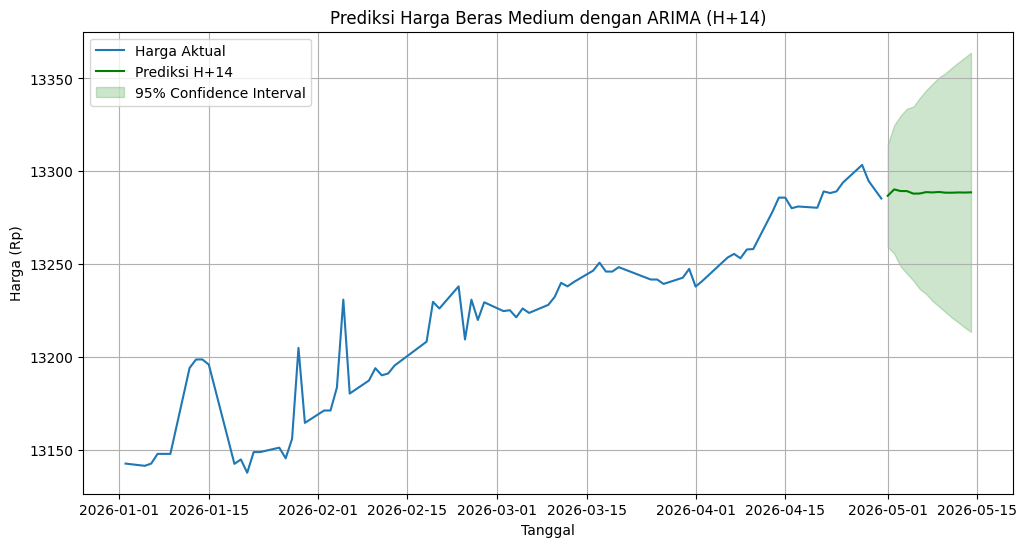

Rangkuman Prediksi 14 Hari ke Depan:
            Prediksi_Harga  Batas_Bawah  Batas_Atas
2026-05-01        13286.84     13259.22    13314.46
2026-05-02        13290.28     13255.73    13324.83
2026-05-03        13289.40     13248.86    13329.93
2026-05-04        13289.37     13244.95    13333.79
2026-05-05        13288.00     13241.18    13334.83
2026-05-06        13288.07     13236.62    13339.52
2026-05-07        13288.82     13233.96    13343.68
2026-05-08        13288.66     13230.15    13347.16
2026-05-09        13288.89     13227.24    13350.55
2026-05-10        13288.53     13224.25    13352.81
2026-05-11        13288.50     13221.23    13355.77
2026-05-12        13288.65     13218.75    13358.55
2026-05-13        13288.59     13215.98    13361.19
2026-05-14        13288.70     13213.55    13363.86


In [7]:
# Retrain dengan Full Data
final_model = ARIMA(df['Price'], order=(5, 1, 0))
final_fitted = final_model.fit()

forecast_days = 14
forecast_result = final_fitted.get_forecast(steps=forecast_days)

# Ambil Prediksi, Batas Bawah (Lower Bound) dan Batas Atas (Upper Bound)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05) # 95% Confidence Interval

future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_days)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Price'], label='Harga Aktual')
plt.plot(future_dates, forecast_mean, color='green', label='Prediksi H+14')

# Area Margin Kepercayaan (Confidence Band)
plt.fill_between(future_dates,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='green', alpha=0.2, label='95% Confidence Interval')

plt.title(f'Prediksi Harga {commodity_name} dengan ARIMA (H+14)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.grid(True)
plt.show()

print("Rangkuman Prediksi 14 Hari ke Depan:")
result_df = pd.DataFrame({
    'Prediksi_Harga': forecast_mean.values,
    'Batas_Bawah': conf_int.iloc[:, 0].values,
    'Batas_Atas': conf_int.iloc[:, 1].values
}, index=future_dates)
print(np.round(result_df, 2))